In [14]:
### 텐서플로 기본

import tensorflow as tf
import numpy as np
import keras

# 텐서플로 그래프 생성하기
g = tf.Graph()
with g.as_default():
    x = tf.compat.v1.placeholder(dtype=tf.float32, shape=(None), name='x')
    w = tf.Variable(2.0, name='weight')
    b = tf.Variable(0.7, name='bias')
    
    z = w * x + b
    
    init = tf.compat.v1.global_variables_initializer()
    
# 세션 만들고 그래프 전달하기
with tf.compat.v1.Session(graph=g) as sess:
    sess.run(init)
    for t in [1.0, 0.6, -1.8]:
        print('x=%4.1f --> z=%4.1f' %(t, sess.run(z, feed_dict={x:t})))
        

x= 1.0 --> z= 2.7
x= 0.6 --> z= 1.9
x=-1.8 --> z=-2.9


In [5]:
with tf.compat.v1.Session(graph=g) as sess:
    sess.run(init)
    print(sess.run(z, feed_dict={x:[1.,2.,3.]}))

print(z)

[2.7 4.7 6.7]
Tensor("add:0", dtype=float32)


In [30]:

# 텐서플로 저수준 API로 Least square problem 풀어보기

X_train = np.arange(10).reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1,
                    2.0, 5.0, 6.3, 
                    6.6, 7.4, 8.0, 
                    9.0])


class TfLinearRegression(object):
    def __init__(self, learning_rate=0.01):
        self.w = tf.Variable(tf.zeros(shape=(1)))
        self.b = tf.Variable(tf.zeros(shape=(1)))
        # 옵티마이저는 SGD로 설정
        self.optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
        
    def fit(self, X, y, num_epochs=10):
        training_cost = []
        
        for step in range(num_epochs):
            with tf.GradientTape() as tape: # 자동 미분을 위해 연산 과정을 기록
                z_net = self.w * X + self.b
                z_net = tf.reshape(z_net, [-1])
                sqr_errors = tf.square(y - z_net)
                mean_cost = tf.reduce_mean(sqr_errors)
                
            grads = tape.gradient(mean_cost, [self.w, self.b])
            self.optimizer.apply_gradients(zip(grads, [self.w, self.b]))
            training_cost.append(mean_cost.numpy())
        
        return training_cost
    
    def predict(self, X):
        return self.w * X + self.b
    

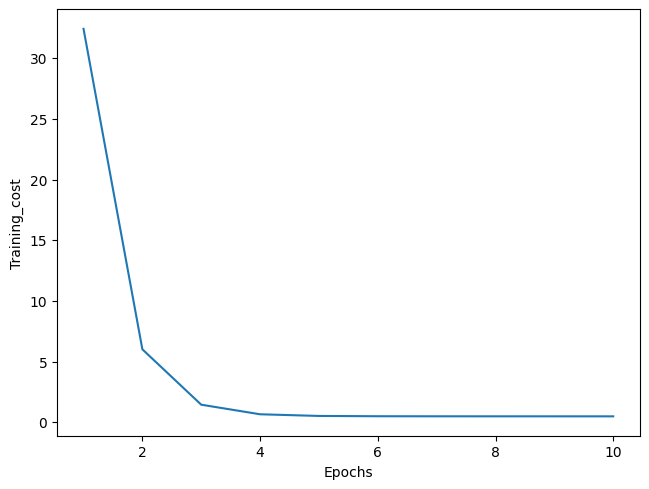

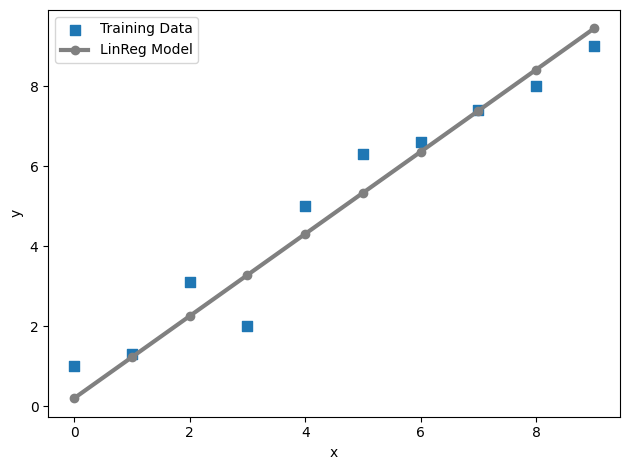

In [32]:

### 만든 모델 사용해보기

import matplotlib.pyplot as plt

lrmodel = TfLinearRegression()
training_costs = lrmodel.fit(X_train, y_train)

# 훈련 그래프
plt.plot(range(1, len(training_costs) + 1), training_costs)
plt.tight_layout()
plt.xlabel('Epochs')
plt.ylabel('Training_cost')
plt.show()


# 예측 그래프
plt.scatter(X_train, y_train,
            marker='s', s=50,
            label='Training Data')
plt.plot(range(X_train.shape[0]), 
         lrmodel.predict(X_train),
         color='gray', marker='o', 
         markersize=6, linewidth=3,
         label='LinReg Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
### 압축 해제 코드
import sys
import gzip
import shutil
import os

if (sys.version_info > (3, 0)):
    writemode = 'wb'
else:
    writemode = 'w'

zipped_mnist = [f for f in os.listdir('./') if f.endswith('ubyte.gz')]
for z in zipped_mnist:
    with gzip.GzipFile(z, mode='rb') as decompressed, open(z[:-3], writemode) as outfile:
        outfile.write(decompressed.read()) 

In [37]:
### 케라스를 이용하여 DNN 구현 (데이터 load 함수 구현)
import os
import struct
 
def load_mnist(path, kind='train'):
    labels_path = os.path.join(path, 
                               '%s-labels-idx1-ubyte' % kind)
    images_path = os.path.join(path, 
                               '%s-images-idx3-ubyte' % kind)
        
    with open(labels_path, 'rb') as lbpath:
        magic, n = struct.unpack('>II', 
                                 lbpath.read(8))
        labels = np.fromfile(lbpath, 
                             dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        magic, num, rows, cols = struct.unpack(">IIII", 
                                               imgpath.read(16))
        images = np.fromfile(imgpath, 
                             dtype=np.uint8).reshape(len(labels), 784)
        images = ((images / 255.) - .5) * 2
 
    return images, labels

In [40]:
### DNN 구현

X_train, y_train = load_mnist('', kind='train')
print("행: %d, 열: %d" %(X_train.shape[0], X_train.shape[1]))

X_test, y_test = load_mnist('', kind='t10k')

# 데이터 전처리
mean_vals = np.mean(X_train, axis=0)
std_val = np.std(X_train)

X_train_centered = (X_train - mean_vals) / std_val
X_test_centered = (X_test - mean_vals) / std_val

del X_train, X_test # 표준화한 데이터셋을 쓸거니 변수 제거

np.random.seed(123)


행: 60000, 열: 784


In [41]:
### TF의 원 핫 인코딩 맛보기

y_train_onehot = tf.keras.utils.to_categorical(y_train)

print("처음 세개 레이블 출력 : ", y_train[:3])
print("원 핫 인코딩된 세개 레이블 출력 : ", y_train_onehot[:3])

처음 세개 레이블 출력 :  [5 0 4]
원 핫 인코딩된 세개 레이블 출력 :  [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [43]:
### Feed-Forward 신경망 만들기

# 모델 만들고 층 추가하기
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Dense(units=50, input_dim=X_train_centered.shape[1],
                                kernel_initializer='glorot_uniform', bias_initializer='zeros', activation='tanh'))
model.add(tf.keras.layers.Dense(units=50, input_dim=50,
                                kernel_initializer='glorot_uniform', bias_initializer='zeros', activation='tanh'))
model.add(tf.keras.layers.Dense(units=y_train_onehot.shape[1], input_dim=50,
                                kernel_initializer='glorot_uniform', bias_initializer='zeros', activation='softmax'))

model.summary()

c:\Users\조승현\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,310 (165.27 KB)

 Trainable params: 42,310 (165.27 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
### 모델 훈련시켜보기

sgd_optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.001, decay=1e-7, momentum=.9)

model.compile(optimizer=sgd_optimizer,
              loss='categorical_crossentropy')

history = model.fit(X_train_centered, y_train_onehot,
                    batch_size=64, epochs=50,
                    verbose=1,
                    validation_split=0.1)

Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0402 - val_loss: 0.1095
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0392 - val_loss: 0.1099
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0382 - val_loss: 0.1100
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0373 - val_loss: 0.1094
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0365 - val_loss: 0.1104
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0355 - val_loss: 0.1107
Epoch 7/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0347 - val_loss: 0.1100
Epoch 8/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0339 - val_loss: 0.1101
Epoch 9/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0331 - val_loss: 0.1108
Epoch 10/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0322 - val_loss: 0.1105
Epoch 11/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0315 - val_loss: 0.1108
Epoch 12/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

In [ ]:
### 클래스 예측

y_train_pred = model.predict(X_train_centered, verbose=0)
print(np.argmax(y_train_pred[:3], axis=-1))

correct_pred = np.sum(y_train == np.argmax(y_train_pred, axis=-1), axis=0)
train_acc = correct_pred / y_train.shape[0]

print("훈련 정확도 %.2f" %(train_acc * 100))

y_test_pred = model.predict(X_test_centered, 
                                    verbose=0)

correct_preds = np.sum(y_test == np.argmax(y_test_pred, axis=-1), axis=0) 
test_acc = correct_preds / y_test.shape[0]
print('테스트 정확도: %.2f%%' % (test_acc * 100))

# 결과값을 보면 약간 Overfitting이 일어난걸 알 수 있음.

[5 0 4]
훈련 정확도 99.62
테스트 정확도: 96.36%


In [ ]:
### activation function의 이해(sigmoid)

X = np.array([1, 1.4, 2.5]) # 첫번째 원소는 1이여야됨. (편향)
w = np.array([0.4, 0.3, 0.5])

def net_input(X, w):
    return np.dot(X, w)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_activation(X, w):
    z = net_input(X, w)
    return sigmoid(z)

print(logistic_activation(X, w))

# 시그모이드 함수는 한개의 출력의 대해서 0~1의 확률값으로 바꿔주는 함수이다.
# 결과값인 0.88은 양성 클래스일 확률이 88% 이란 소리이다.


0.8879529614430097


In [ ]:
### 한개의 클래스가 아닌 다중 클래스를 비교할땐?

# 여러개의 뉴런에 대한 가중치
W = np.array([[1.1, 1.2, 0.8, 0.4],
              [0.2, 0.4, 1.0, 0.2],
              [0.6, 1.5, 1.2, 0.7]])
A = np.array([[1, 0.1, 0.4, 0.6]])
z = np.dot(W, A[0])

y_probas = sigmoid(z)
print(z) # 최종 입력

print(y_probas) # 최종 출력

# 결과를 보면 확률의 합이 1이 아니기 때문에 몇번 클래스의 소속될 확률이라고 표현할 수 없다.
# 하지만 결과를 예측할땐 제일 큰 확률로 예측하면 되기에 예측만 할땐 문제되진 않는다.
# np.argmax()를 통해서 제일 큰 확률을 해달 뉴런의 클래스로 예측


# 다중 클래스 분류를 위한 activation function 정의
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

y_prob = softmax(z)
print(y_prob)

# softmax의 결과값은 확률의 합이 1이기 때문에 어느 클래스에 소속될 확률이라고 말할 수 있다.


[1.78 0.76 1.65]
[0.85569687 0.68135373 0.83889105]
[0.44668973 0.16107406 0.39223621]


In [ ]:
# 하이퍼볼릭 탄젠트 (tanh)

import matplotlib.pyplot as plt

def tanh(z):
    e_p = np.exp(z)
    e_m = np.exp(-z)
    
    return (e_p - e_m) / (e_p + e_m)

z = np.arange(-5, 5, 0.005)
log_act = sigmoid(z)
tanh_act = tanh(z)

plt.ylim([-1.5, 1.5])
plt.xlabel('net input $z$')
plt.ylabel('activation $\phi(z)$')
plt.axhline(1, color='black', linestyle=':')
plt.axhline(0.5, color='black', linestyle=':')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(-0.5, color='black', linestyle=':')
plt.axhline(-1, color='black', linestyle=':')

plt.plot(z, tanh_act,
         linewidth=3, linestyle='--',
         label='tanh')

plt.plot(z, log_act,
         linewidth=3,
         label='logistic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()